In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from  matplotlib.ticker import FuncFormatter
%matplotlib inline


In [2]:
import setmorph as sm

In [3]:
paths = [
        ("arabic", "ar"),
        ("french", "fr"),
        ("ngkolmpu", "ng"),
        ("nuer", "nuer"),
        ("russian", "rus"),
        ("zenzontepec chatino", "zen"),
         ]

In [4]:
def collate_data(languages):
    paths = ["results/{lg}_analysis__values_per_word.csv",
             "results/{lg}_analysis__values.csv",
             "results/{lg}_analysis__formatives.csv",
             "src/setmorph/testdata/sample-{lg}-out.csv"]
    data = ([], [], [], [])
    for lg, key in languages:
        for path, dfs in zip(paths, data):
            if "analysis" in path:
                df = pd.read_csv(path.format(lg=key))
            else:
                df = sm.read_paradigms(path.format(lg=key))
            df["Language"] = lg
            dfs.append(df)

    return tuple(pd.concat(dfs).reset_index() for dfs in data)

In [20]:
vals_w, vals, forms, paradigms = collate_data(paths)

In [7]:
plot_kwargs = dict(hue="Language", col="Language", height=8, aspect=1, discrete=True, stat='percent', common_norm=False)

# Traditional measures

Synthesis index: formatives / words

In [122]:

# Initially, rows are formatives
# Each word is a quadruplet of language, cell, lexeme & form
# We group formatives per row and count them, to get number of formatives per word
# We then group per language and average
word_identifiers = ["Language", "cell", "lexeme", "form"]
fm_relation = paradigms.groupby(word_identifiers)\
    .agg({"celllist": lambda vs: len(vs.iloc[0]),
          "formative": lambda fs: fs.shape[0]
          })
fm_relation.columns = ["fvalues", "formatives"]

synthesis = fm_relation["formatives"].groupby(level=0).mean()
synthesis.name = "synthesis"
synthesis

Language
arabic                 4.355311
french                 3.011364
ngkolmpu               5.009091
nuer                   3.208333
russian                4.094421
zenzontepec chatino    4.552632
Name: synthesis, dtype: float64

Fusionnal index: two acceptions

1. At the level of the lexicon: formatives / feature-values
    Higher = more fusion.

Note that I count this per word: how many feature-values in the cell, how many formatives in the segmented word. This is not very subtle: if there are two formatives, both cumulative between two f-v, we get 2/2=1, although this is more fusional than having two formatives, each of which express a single of the two f-v.

Is this wrong ?


In [123]:
fusion = fm_relation.groupby(level=0).mean().apply(lambda row: row.formatives/row.fvalues, axis=1)
fusion.name = "fusion"

In [125]:
indexes_fs = pd.merge(fusion, synthesis, left_index=True, right_index=True)

We can right away visualize the relation:

(0.0, 4.743968896600475)

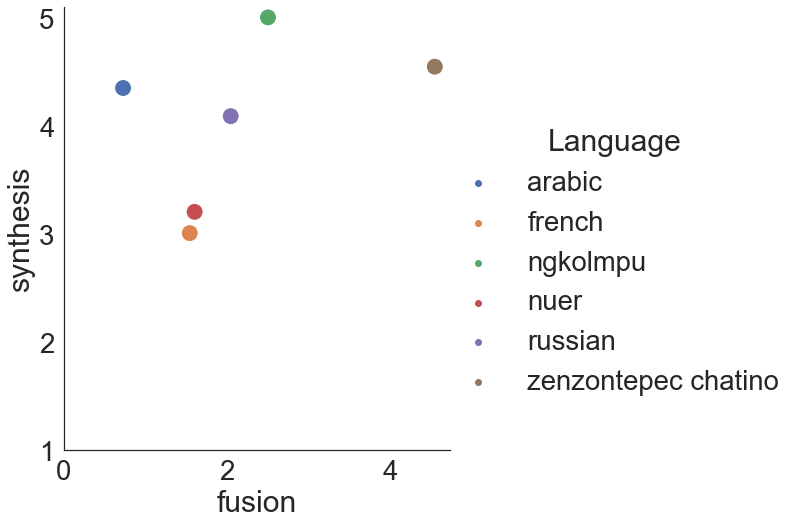

In [126]:
sns.relplot(data=indexes_fs, x="fusion", y="synthesis", hue="Language",  height=8, aspect=1, s=300)

plt.ylim(1, None)
plt.xlim(0, None)

They are correlated, but for a good reason, which is that one is the count of formatives per word, and the other is the count of formative per word, divided by the count of values per word.

(0.0, 10.0)

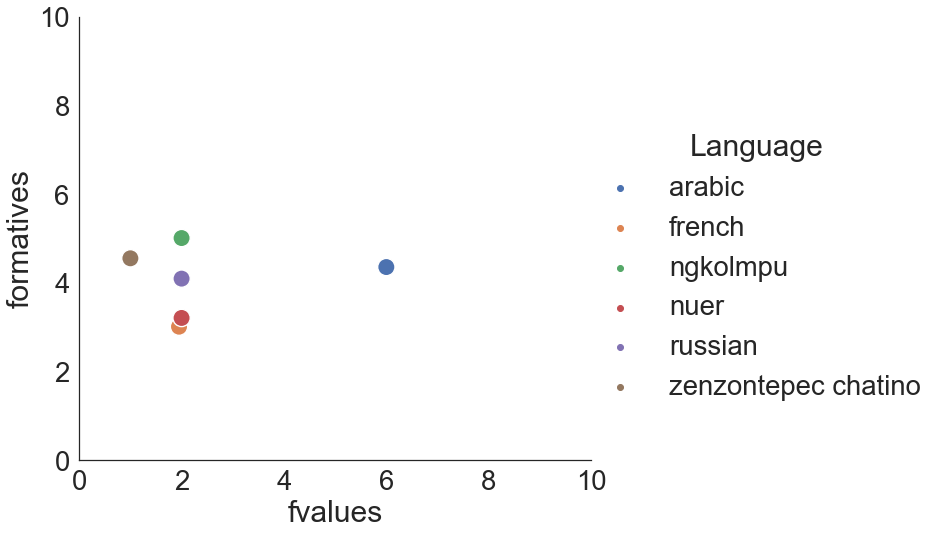

In [137]:
sns.relplot(data=fm_relation.groupby(level=0).mean(), y="formatives", x="fvalues", hue="Language",  height=8, aspect=1.2, s=300)

plt.ylim(0, 10)
plt.xlim(0, 10)

(0.0, 10.0)

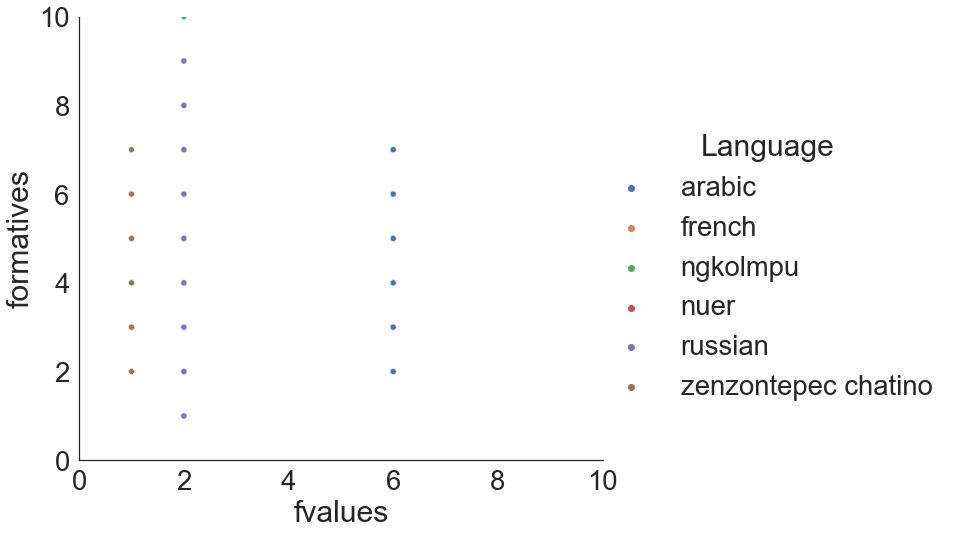

In [139]:
sns.relplot(data=fm_relation, y="formatives", x="fvalues", hue="Language", row="Language",  height=8, aspect=1.2)

plt.ylim(0, 10)
plt.xlim(0, 10)

Ok, so the problem here, to start with, is that each language has only a single number of values per word (eg. all words are combinations of a gender and a number).

In [ ]:

2. Greenberg's index of agglutination:
    Agglutinative construction / junctures


In [24]:
paradigms[paradigms.form == "r u kʲ 'i"]

,index,lexeme,cell,form,tier,slot,formative,celllist,Language
3724,505,ruk'a,genitive.singular,r u kʲ 'i,segmental,0,ruk,"(genitive, singular)",russian
3725,506,ruk'a,genitive.singular,r u kʲ 'i,segmental,3,i,"(genitive, singular)",russian
3752,533,ruk'a,genitive.singular,r u kʲ 'i,palatalization,0,ʲ,"(genitive, singular)",russian
3759,540,ruk'a,genitive.singular,r u kʲ 'i,stress,0,',"(genitive, singular)",russian


# Formatives

We first look at the number of values expressed per formative.
- 0 corresponds stems
- 1 corresponds to simple exponence
- 2+ corresponds to syncretism

Of course, this is limited by the number of cells => For nuer we have only sg/pl so no more than 1 values can be expressed. It is always $n-1$ given $n$ cells.

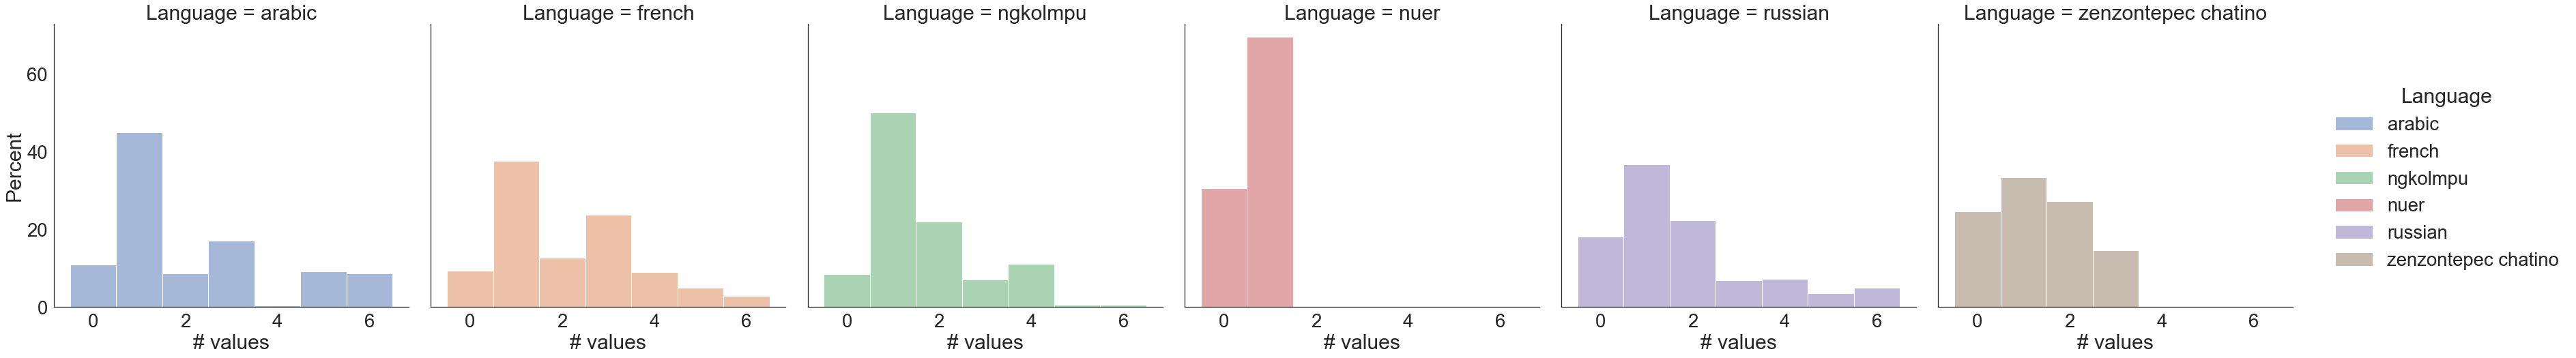

In [8]:

sns.displot(forms, x="# values", **plot_kwargs)
sns.despine()

In [ ]:
Discretize: 1 vs not-1

/home/sacha/anaconda3/envs/segment/lib/python3.9/site-packages/seaborn/distributions.py:461: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/home/sacha/anaconda3/envs/segment/lib/python3.9/site-packages/seaborn/distributions.py:462: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


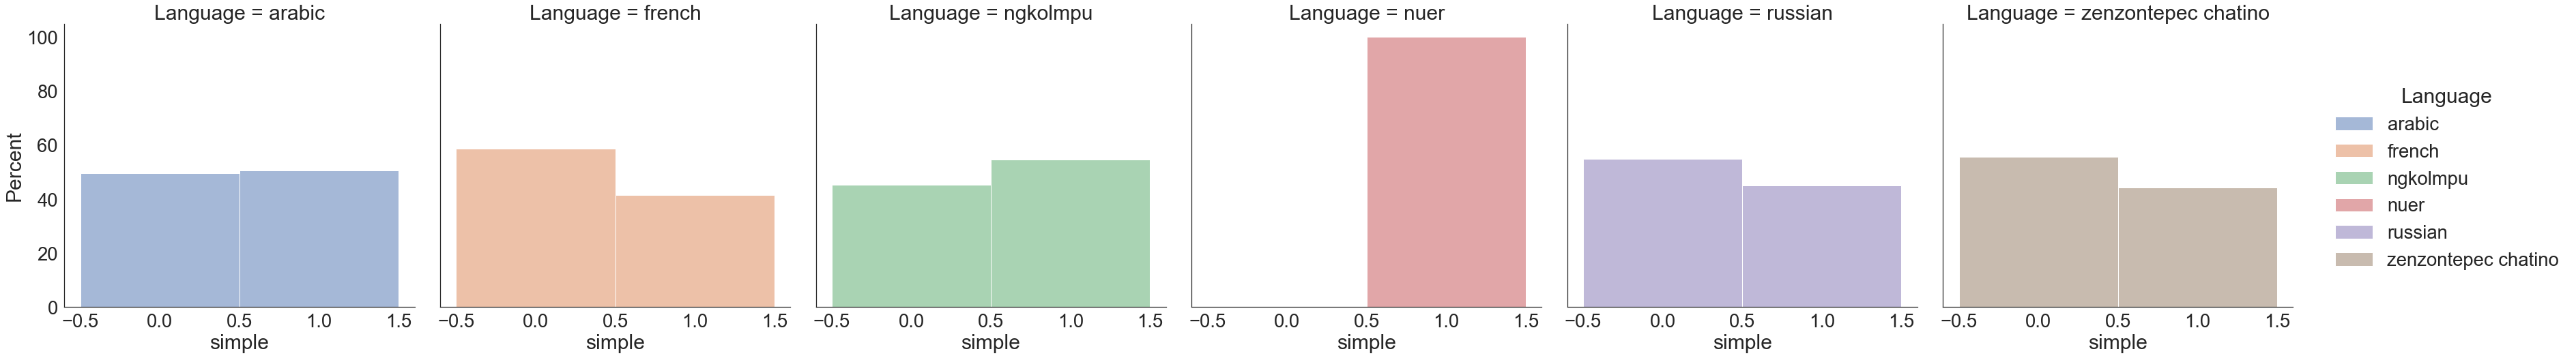

In [12]:
forms["simple"] = (forms["# values"] == 1)

sns.displot(forms[forms["# values"] != 0], x="simple", **plot_kwargs)
sns.despine()

Cardinality of values: corresponds to cumulative exponence.
- If 0: not cumulative
- above 0: cumulative

Note: why is 1 not present ? => TODO: "longest cumulation" => "longest exponence set"

This one is artificially bounded by the fact that we made toy sets with few dimensions !

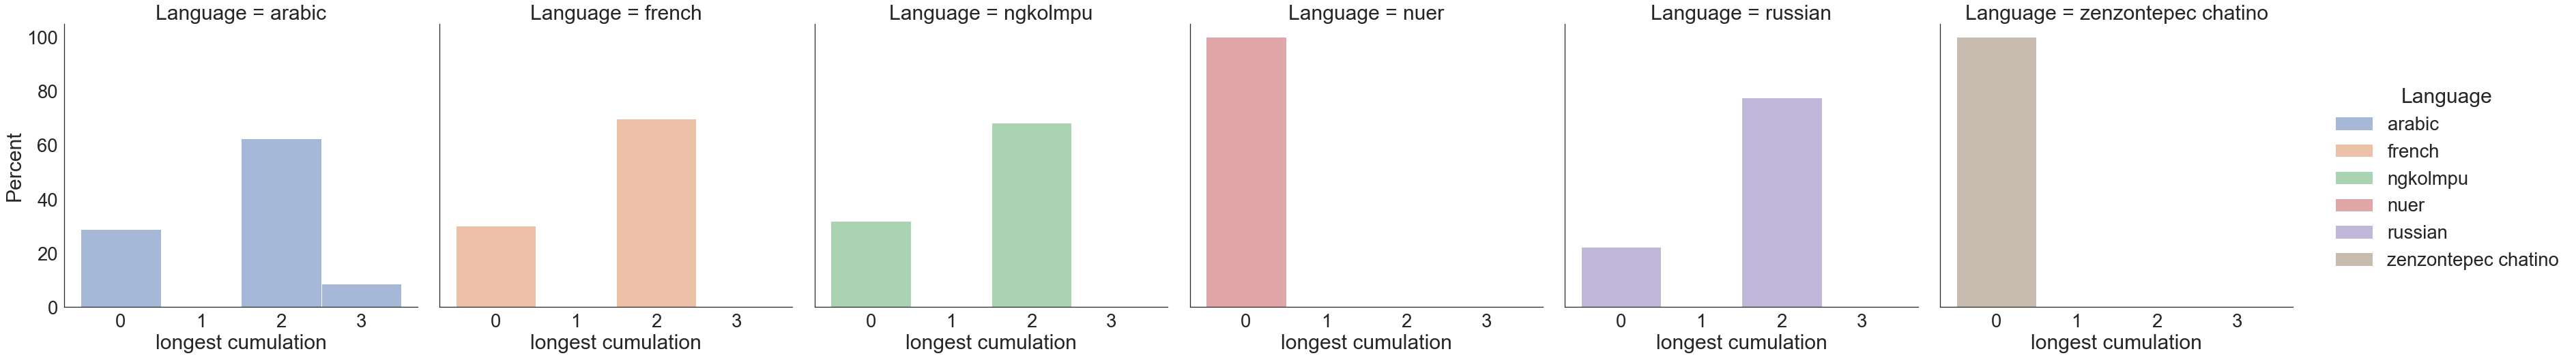

In [13]:

sns.displot(forms, x="longest cumulation", **plot_kwargs)
sns.despine()

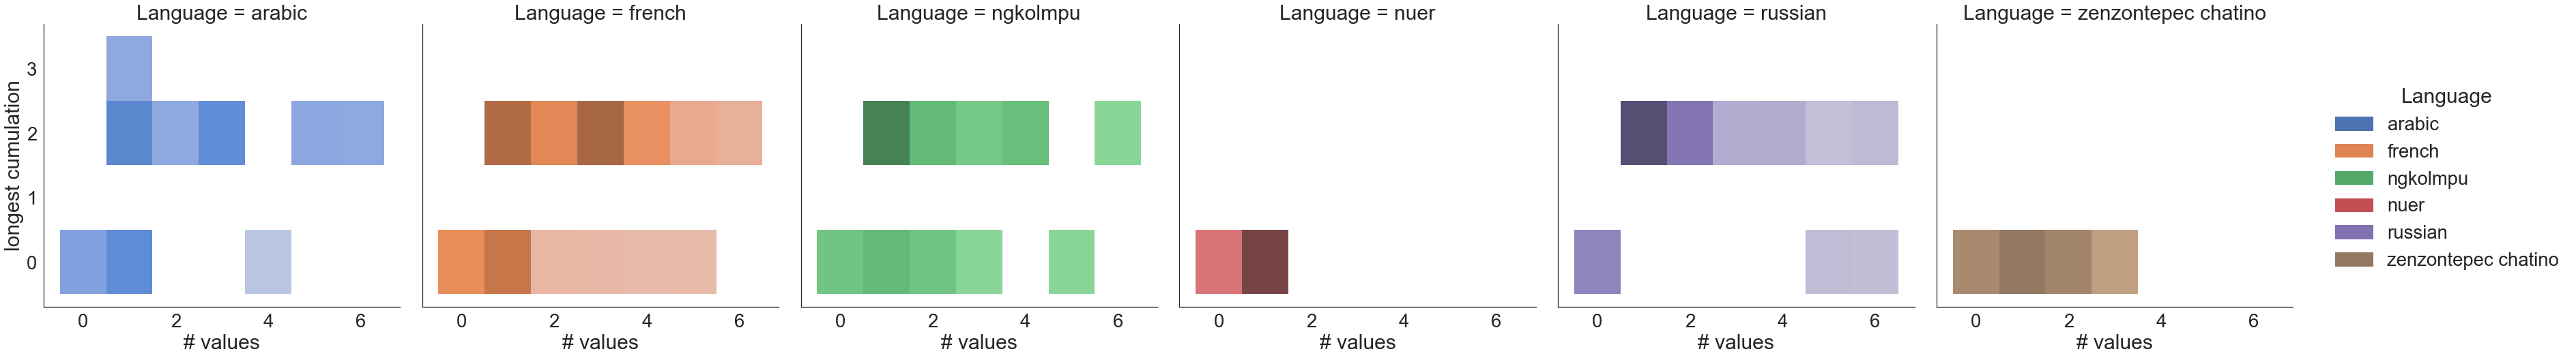

In [14]:

sns.displot(forms,  x="# values", y="longest cumulation", hue="Language", col="Language", height=8, aspect=1, discrete=True)
sns.despine()

## Values

Our measures are about unique exponence & allomorphy:

- Number of formatives: if 1, then this is unique exponence. If > 1: non-unique exponence.
- Number of allomorph sets: if 1, no allomorphy. The higher, the more allomorphy.
- Number of words: number of distint words (either overabundant or from different cells) expressing this value.
- % of allomorphs to words


In [16]:

import matplotlib.ticker as ticker

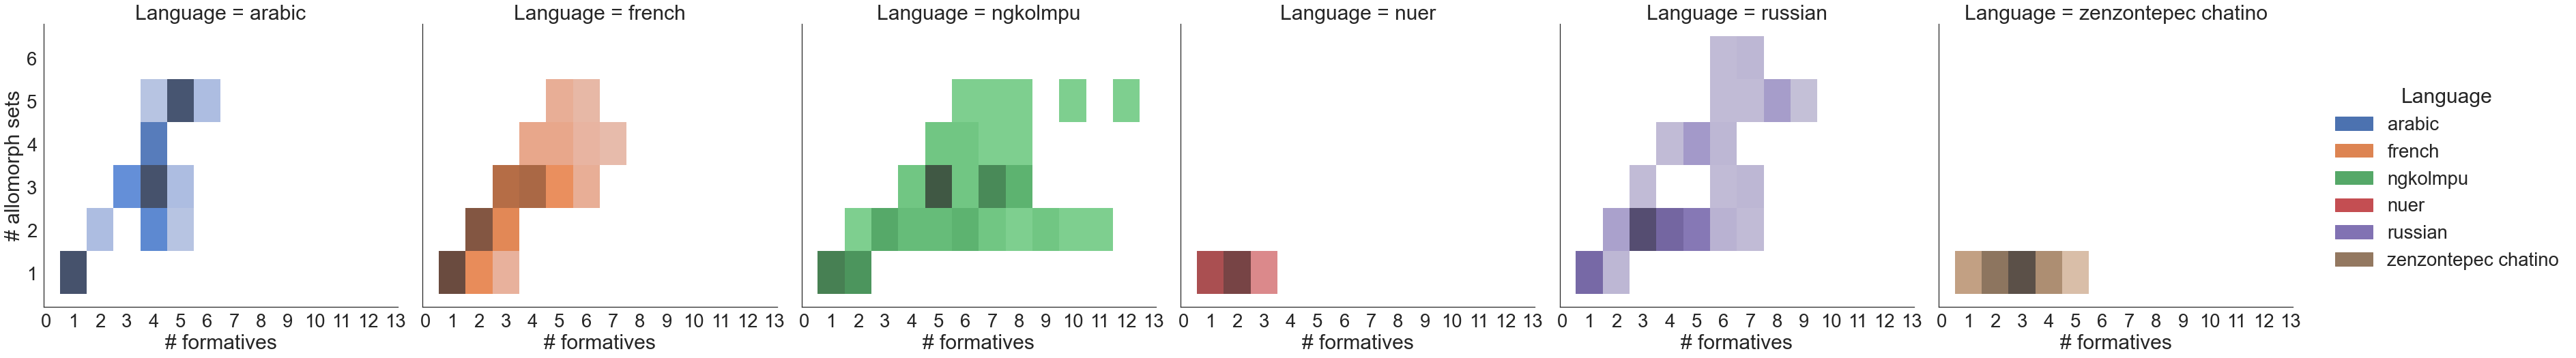

In [17]:

p = sns.displot(vals,  x="# formatives", y="# allomorph sets", **plot_kwargs)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(base=1))
#plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
sns.despine()

In [13]:
vals

,index,lexeme,value,formative,formatives_by_word,# formatives,# allomorph sets,# words,% allomorph to words,Language
0,0,danā,1,<segmental_2_uː>,#<segmental_2_uː>#,1,1,2,50.000000,arabic
1,1,danā,2,<segmental_4_a> <segmental_2_iː> <segmental_0_...,#<segmental_0_t># #<segmental_0_t> <segmental_...,5,5,5,100.000000,arabic
2,2,danā,3,<segmental_2_uː> <segmental_4_a> <segmental_0_...,#<segmental_0_j># #<segmental_0_j> <segmental_...,4,4,6,66.666667,arabic
3,3,danā,d,<segmental_0_t> <segmental_2_uwaː> <segmental_...,#<segmental_2_uwaː> <segmental_3_n> <segmental...,4,2,3,66.666667,arabic
4,4,danā,f,<segmental_0_t> <segmental_4_a> <segmental_2_i...,#<segmental_0_t> <segmental_2_iː> <segmental_3...,4,3,5,60.000000,arabic
...,...,...,...,...,...,...,...,...,...,...
767,68,yu¹kų²ʔ,pot,<segmental_2_tʃ>,#<segmental_2_tʃ>#,1,1,1,100.000000,zenzontepec chatino
768,69,yu¹kų²ʔ,prog,<segmental_2_tʃ> <segmental_0_n> <tone_0_⁰> <s...,#<segmental_0_n> <segmental_1_te> <segmental_2...,4,1,1,100.000000,zenzontepec chatino
769,70,ʔne⁰,cpl,<tone_1_⁰> <segmental_2_k> <segmental_0_n> <se...,#<segmental_0_n> <segmental_2_k> <segmental_3_...,4,1,1,100.000000,zenzontepec chatino
770,71,ʔne⁰,hab,<tone_1_⁰> <tone_0_⁰> <segmental_2_al> <segmen...,#<segmental_1_t> <segmental_2_al> <segmental_3...,5,1,1,100.000000,zenzontepec chatino


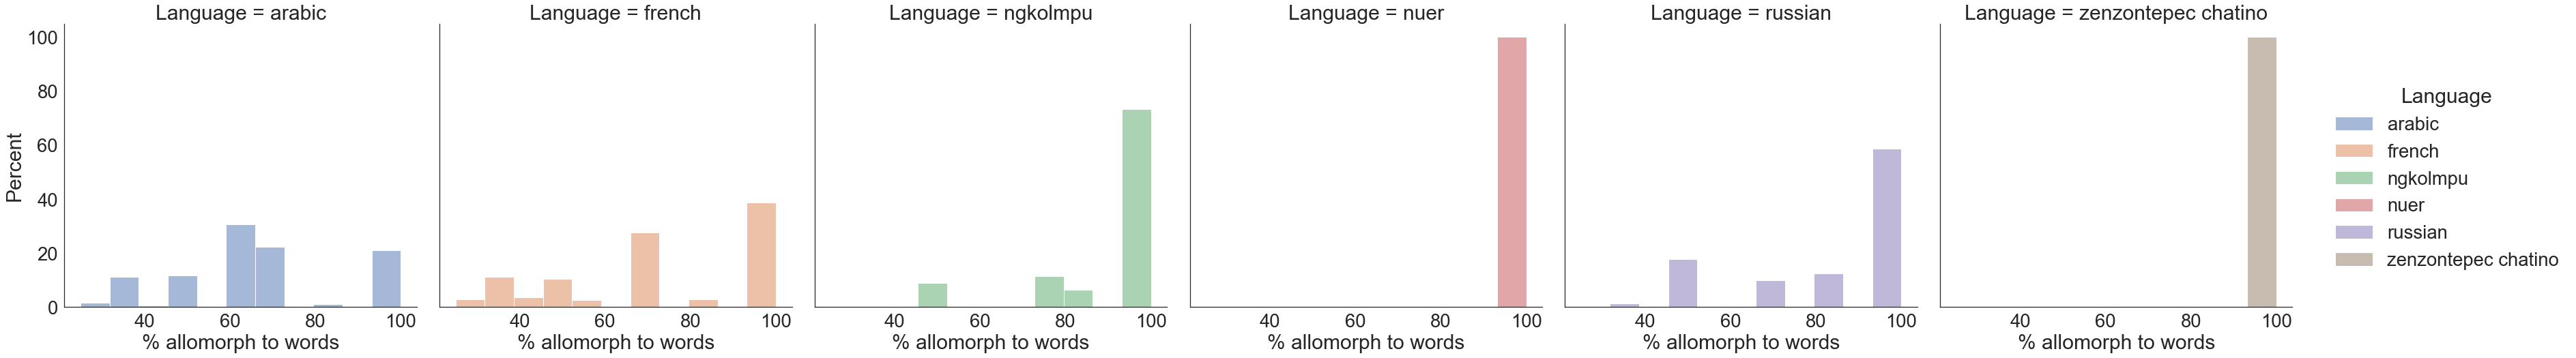

In [18]:
p = sns.displot(vals,  x="% allomorph to words", **dict(plot_kwargs, discrete=False))
sns.despine()

Verbose exponence:
- If a value in a given word is expressed by more than 1 formative, then it is verbose exponence !

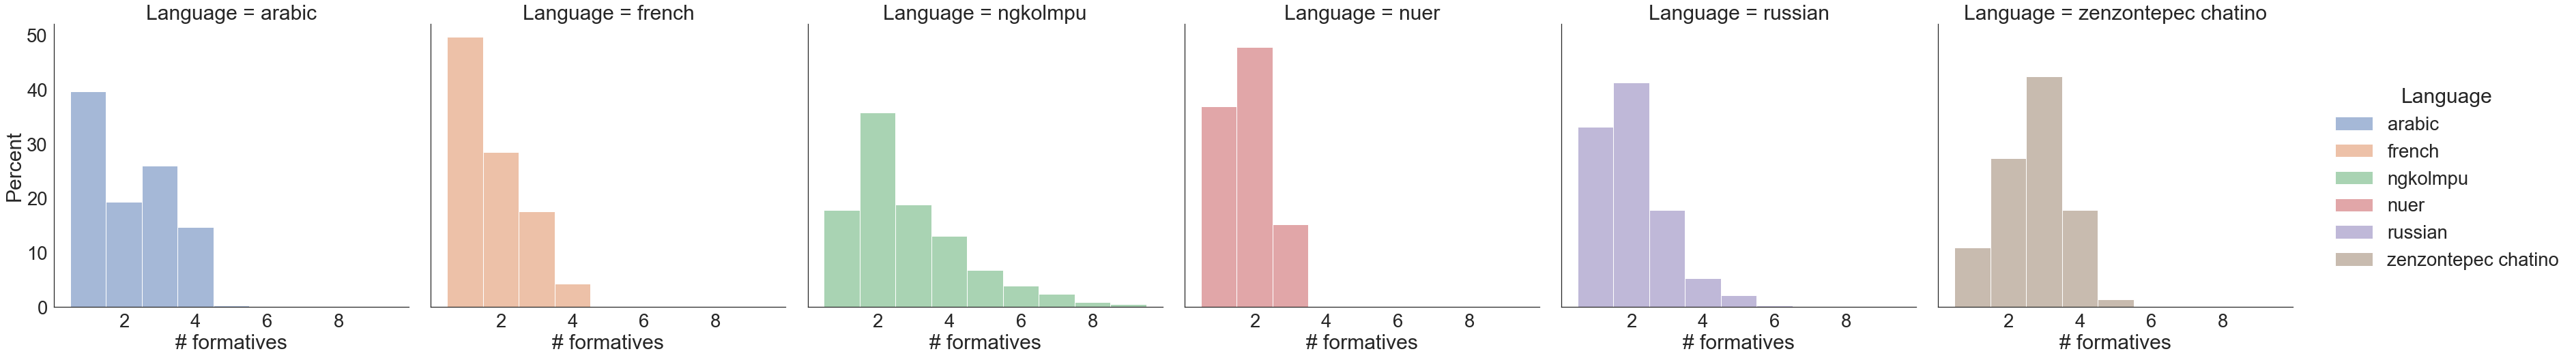

In [19]:

p = sns.displot(vals_w,  x="# formatives", **plot_kwargs)
sns.despine()

/home/sacha/anaconda3/envs/segment/lib/python3.9/site-packages/seaborn/distributions.py:461: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(edges, name="edges"),
/home/sacha/anaconda3/envs/segment/lib/python3.9/site-packages/seaborn/distributions.py:462: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pd.Index(widths, name="widths"),


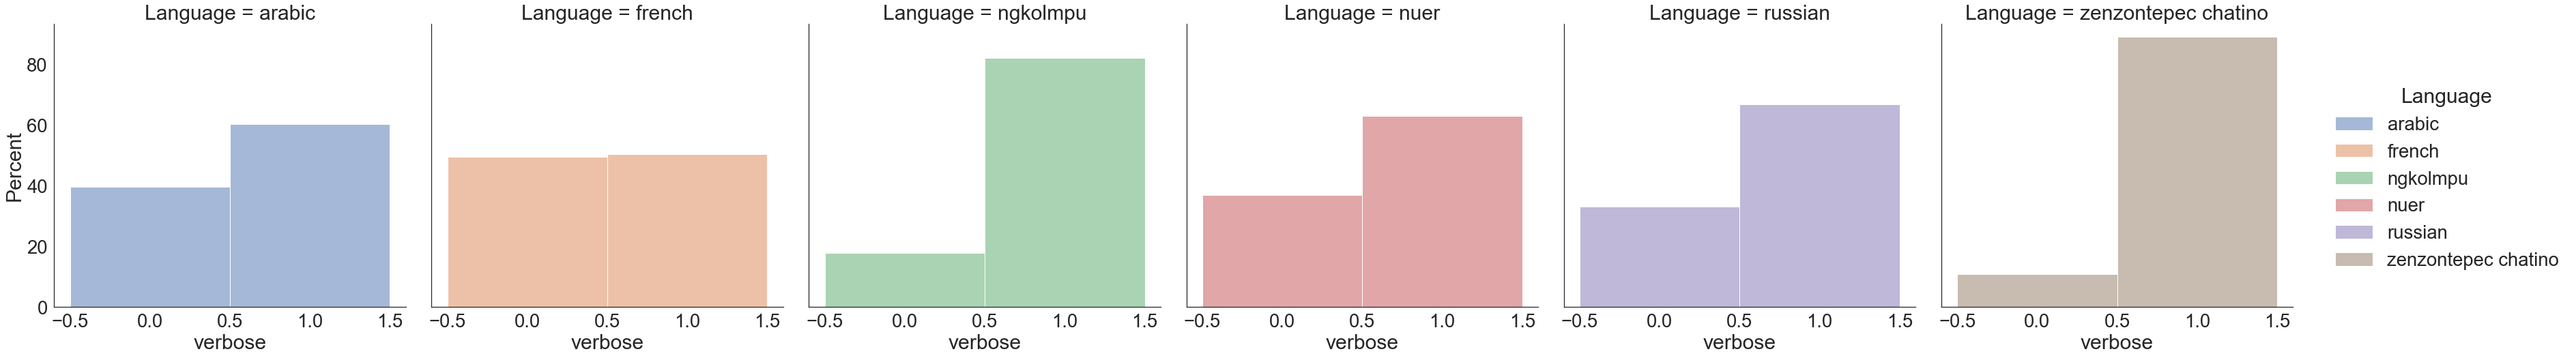

In [21]:
vals_w["verbose"] = (vals_w["# formatives"] > 1)

sns.displot(vals_w[vals_w["# formatives"] != 0], x="verbose", **plot_kwargs)
sns.despine()